## Results for mixture toy example

In [ ]:
import numpy as np
import pandas as pd
import glob
import pickle
import os
import sys

from scipy.stats import gaussian_kde
from sklearn.cluster import KMeans
from scipy.spatial import Voronoi
from shapely.geometry import Polygon

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
import matplotlib.cm as cm
import seaborn as sns


parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.extend([parent_dir])
OUTDIR = os.path.join(parent_dir,'mixture_outputs')
PLOTDIR = os.path.join(parent_dir,'plots/mixture')
if not os.path.exists(PLOTDIR):
    os.makedirs(PLOTDIR)

PATTERN = "mixture_outputs_*.npz"
files = sorted(glob.glob(os.path.join(OUTDIR, PATTERN)))

NCLUSTERS = 3

from FastKernCP.utils import *

In [ ]:
BASE_SEED = 214
NTRIALS = 50
NCNT = 1000
NSAMPLE = 2000
NFEATURES = 1000
NMIXTURES = 3
test_prop = 0.1
calib_prop = 0.3
alpha = 0.1
NBINS = 10

In [3]:
with open(os.path.join(OUTDIR,'all_list.pkl'), 'rb') as f:
    all_dist = pickle.load(f)
calib = all_dist[0]

kde = gaussian_kde(calib.T, bw_method='scott')
density = kde(calib.T)
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
kmeans.fit(calib, sample_weight=density)

,n_clusters,10
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [ ]:
methods_to_include = [
    ("SpeedCP",  "speedcp_covers",    "speedcp_cutoffs",    "speedcp_time"),
    ("CondCP",    "condconf_covers",    "condconf_cutoffs",    "condconf_time"),
    ("SplitCP",    "scp_covers",         "scp_cutoffs",         "scp_time"),
    ("PCP",         "pcp_covers",         "pcp_cutoffs",         "pcp_time"),
    ("RLCP",        "rlcp_covers",        "rlcp_cutoffs",        "rlcp_time"),
]

method_names = [m[0] for m in methods_to_include]

W_all = []
covers_list = {method: [] for method in method_names}
cutoffs_list = {method: [] for method in method_names}

coverage_df = pd.DataFrame()

files = files[:50]
for f in files:
    d = np.load(f, allow_pickle=True)
    seed = d["seed"]
    W_test = d['W_test']
    W_all.append(W_test)

    # Predict bins
    W_cart = barycentric_to_cartesian(W_test)
    bin_membership = kmeans.predict(W_cart)
    W_with_bins = np.hstack([W_test, bin_membership[:, None]])

    # Get topics
    topics = np.argmax(d['W_test'], axis=1)

    for method_name, cov_key, cutoff_key, time_key in methods_to_include:
        cutoffs = d[cutoff_key]
        covers = d[cov_key]

        if method_name in ["CondCP", "CondCP (Bin)"]:
            cutoffs = np.concatenate(cutoffs)
            covers = d['resid_test'] <= cutoffs
            covers = covers.astype(int)
        
        if method_name == 'SplitCP':
            cutoffs = np.array([cutoffs]*len(W_test))

        covers_list[method_name].append(covers)
        cutoffs_list[method_name].append(cutoffs)
        runtime = d[time_key]

        # Marginal coverage
        coverage_df = pd.concat([
            coverage_df,
            pd.DataFrame([{
                "seed": seed,
                "coverage": 1 - np.mean(covers),
                "shift_type": "Marginal",
                "time": runtime,
                "cutoff": np.mean(cutoffs),
                "method": method_name
            }])
        ], ignore_index=True)

        for k in range(NCLUSTERS):
            idx = np.where(topics == k)[0]
            shiftcov = np.mean(covers[idx])
            shiftcutoffs = np.mean(cutoffs[idx])
            coverage_df = pd.concat([
                coverage_df,
                pd.DataFrame([{
                    "seed": seed,
                    "coverage": 1 - shiftcov,
                    "shift_type": 'Cluster'+str(k+1),
                    "time": runtime,
                    "cutoff": shiftcutoffs,
                    "method": method_name
                }])
            ], ignore_index=True)
        
        for k in range(NBINS):
            idx = np.where(W_with_bins[:,3]==k)[0]
            shiftcov = np.mean(covers[idx])
            shiftcutoffs = np.mean(cutoffs[idx])
            coverage_df = pd.concat([
                coverage_df,
                pd.DataFrame([{
                    "seed": seed,
                    "coverage": 1 - shiftcov,
                    "shift_type": 'Bin'+str(k+1),
                    "time": runtime,
                    "cutoff": shiftcutoffs,
                    "method": method_name
                }])
            ], ignore_index=True)



## Plot calibration and test densities

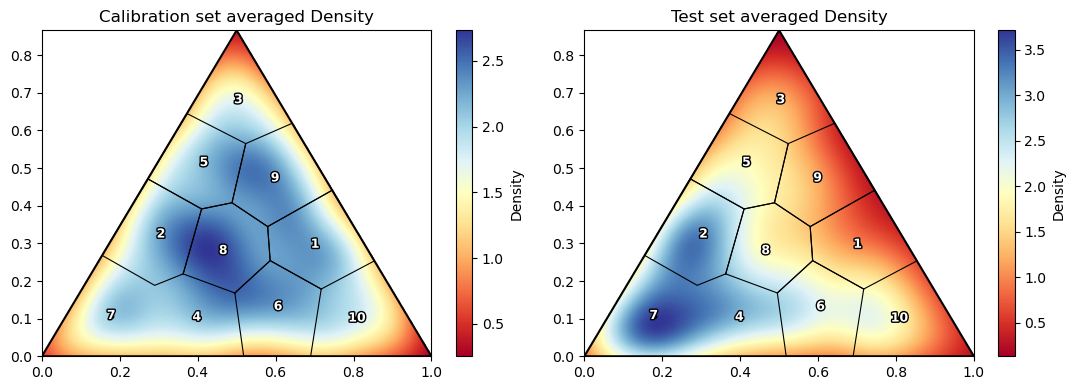

In [6]:
def barycentric_to_cartesian(p):
    """ Map (p1, p2, p3) probability vector to 2D Cartesian coordinates in simplex """
    x = 0.5 * (2*p[:,1] + p[:,2]) / (p[:,0] + p[:,1] + p[:,2])
    y = (np.sqrt(3)/2) * p[:,2] / (p[:,0] + p[:,1] + p[:,2])
    return np.column_stack((x, y))

grid_size = 300
x = np.linspace(0, 1, grid_size)
y = np.linspace(0, np.sqrt(3)/2, grid_size)
X, Y = np.meshgrid(x, y)
positions = np.vstack([X.ravel(), Y.ravel()])
mask = (Y.flatten() <= (-np.sqrt(3)*X.flatten() + np.sqrt(3))) & (Y.flatten() <= (np.sqrt(3)*X.flatten()))

centroids = kmeans.cluster_centers_
vor = Voronoi(centroids)

# --- Plot ---
fig, axs = plt.subplots(1,2, figsize=(11, 4))
cmap = plt.cm.RdYlBu
norm = Normalize(vmin=0, vmax=50)

titles = ["Calibration set averaged Density", "Test set averaged Density"]
for l, arr in enumerate(all_dist):
    kde = gaussian_kde(arr.T, bw_method='scott')
    density = kde(positions)
    density = density.reshape(grid_size, grid_size)
    density = np.where(mask.reshape(grid_size, grid_size), density, np.nan)  # mask outside

    triangle = np.array([[0,0], [1,0], [0.5,np.sqrt(3)/2], [0,0]])
    
    ax = axs[l]
    heatmap = ax.imshow(
                    density,
                    origin='lower',
                    extent=[0, 1, 0, np.sqrt(3)/2],
                    cmap=cmap,
                    aspect='auto'
                )
    
    simplex_polygon = Polygon(triangle[:3])
    
    ax.plot(triangle[:,0], triangle[:,1], color='black')

    for i, region_index in enumerate(vor.point_region):
        region = vor.regions[region_index]
        if -1 in region or len(region) == 0:
            continue
        try:
            poly = Polygon([vor.vertices[j] for j in region])
            clipped = poly.intersection(simplex_polygon)
            if clipped.is_empty:
                continue
            if clipped.geom_type == "Polygon":
                x, y = clipped.exterior.xy
                ax.plot(x, y, color='black', lw=0.8)
            elif clipped.geom_type == "MultiPolygon":
                for subpoly in clipped:
                    x, y = subpoly.exterior.xy
                    ax.plot(x, y, color='black', lw=0.8)
        except:
            continue

    ax.scatter(centroids[:, 0], centroids[:, 1], s=10, c='black')

    for j, (x, y) in enumerate(centroids):
        ax.text(
            x, y, str(j+1),
            ha='center', va='center',
            fontsize=9, weight='bold', color='white',
            zorder=4,
            path_effects=[pe.withStroke(linewidth=2, foreground='black')]
        )

    plt.colorbar(heatmap, ax=ax, label="Density")
    axs[l].set_xlim(0, 1)
    ax.set_ylim(0, np.sqrt(3)/2)
    ax.set_title(titles[l])
plt.tight_layout()
plt.show()

## Plot coverage for each dominant mixture component

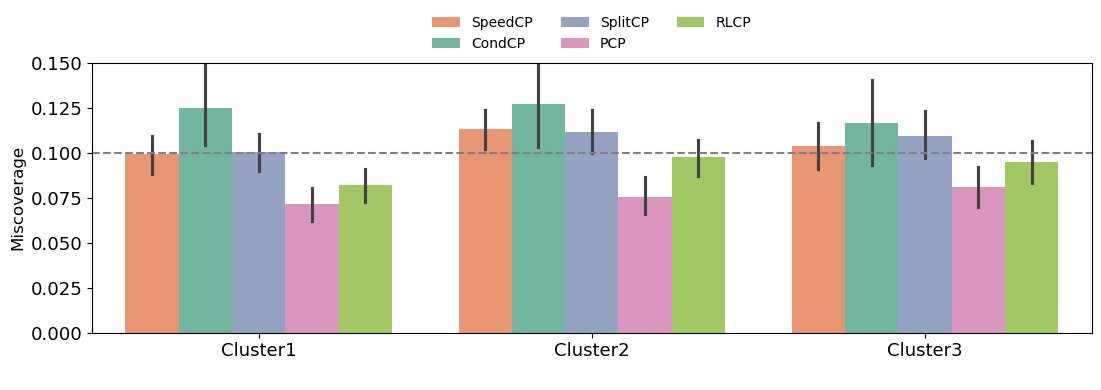

In [7]:
original_palette = sns.color_palette("Set2", n_colors=len(method_names))

reddest_index = max(range(len(original_palette)), key=lambda i: original_palette[i][0])

swapped_palette = original_palette.copy()
swapped_palette[0], swapped_palette[reddest_index] = swapped_palette[reddest_index], swapped_palette[0]
palette = dict(zip(method_names, swapped_palette))

# Create a single plot
fig, ax = plt.subplots(figsize=(11, 4))

coverage_df["shift_type"] = coverage_df["shift_type"].astype(str)

# Create boxplot
sns.barplot(data=coverage_df[coverage_df['shift_type'].str.startswith('Cluster')], 
            x="shift_type", y="coverage", hue="method", 
            palette=palette, ax=ax)
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,
)
ax.set_ylim(0, 0.15)
ax.axhline(0.1, color='gray', linestyle='--', label="target miscoverage")
ax.set_xlabel(" ")
ax.set_ylabel("Miscoverage", fontsize = 12)
plt.xticks(rotation=0)
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)
plt.tight_layout()

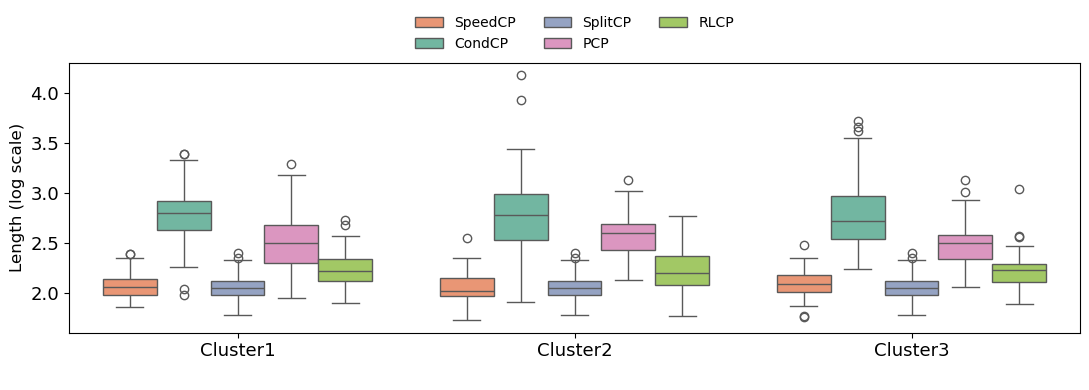

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))

coverage_df["shift_type"] = coverage_df["shift_type"].astype(str)

# Create boxplot
sns.boxplot(data=coverage_df[coverage_df['shift_type'].str.startswith('Cluster')], 
            x="shift_type", y="cutoff", hue="method", 
            palette=palette, ax=ax)
legend = sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,
)
if legend:
    for text in legend.get_texts():
        text.set_fontsize(14)

# Set y-axis to log scale
ax.set_yscale('log')
ax.set_xlabel(" ")
ax.set_ylabel("Length (log scale)", fontsize = 12)
plt.xticks(rotation=0)
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)
plt.tight_layout()

## Plot coverage for partitions across the simplex

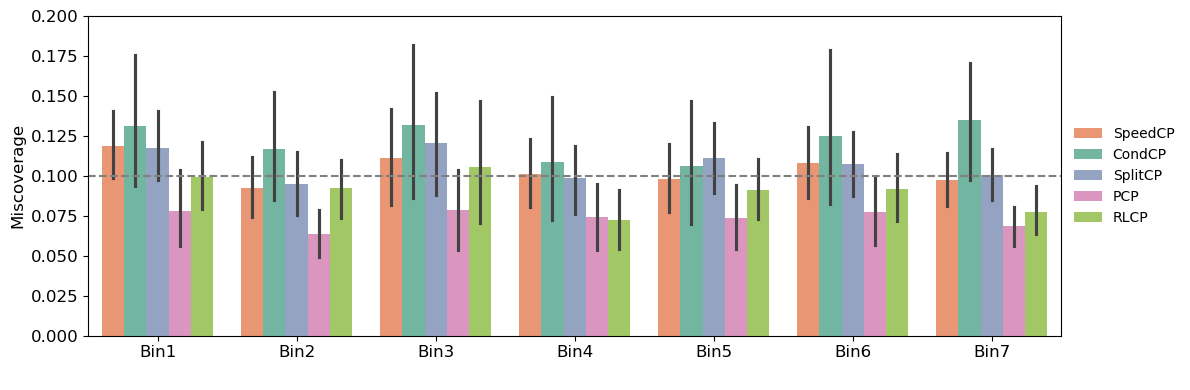

In [10]:
original_palette = sns.color_palette("Set2", n_colors=len(method_names))

reddest_index = max(range(len(original_palette)), key=lambda i: original_palette[i][0])

swapped_palette = original_palette.copy()
swapped_palette[0], swapped_palette[reddest_index] = swapped_palette[reddest_index], swapped_palette[0]
palette = dict(zip(method_names, swapped_palette))

# Create a single plot
fig, ax = plt.subplots(figsize=(12, 4))

coverage_df["shift_type"] = coverage_df["shift_type"].astype(str)

# Create boxplot
sns.barplot(data=coverage_df[coverage_df['shift_type'].str.startswith('Bin')], 
            x="shift_type", y="coverage", hue="method", 
            palette=palette, ax=ax)
legend = sns.move_legend(
    ax, "center left",
    bbox_to_anchor=(1, 0.5), ncol=1, title=None, frameon=False,
)
if legend:
    for text in legend.get_texts():
        text.set_fontsize(14)
ax.set_ylim(0, 0.2)
ax.axhline(0.1, color='gray', linestyle='--', label="target miscoverage")
ax.set_xlabel(" ")
ax.set_ylabel("Miscoverage", fontsize = 12)
plt.xticks(rotation=0)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.tight_layout()

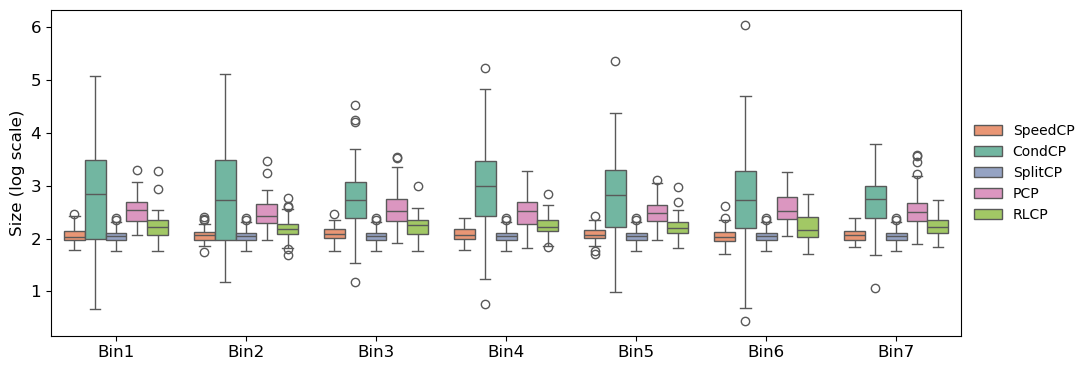

In [11]:
# Create a single plot
fig, ax = plt.subplots(figsize=(11, 4))

coverage_df["shift_type"] = coverage_df["shift_type"].astype(str)

# Create boxplot
sns.boxplot(data=coverage_df[coverage_df['shift_type'].str.startswith('Bin')], 
            x="shift_type", y="cutoff", hue="method", 
            palette=palette, ax=ax)
legend = sns.move_legend(
    ax, "center left",
    bbox_to_anchor=(1, 0.5), ncol=1, title=None, frameon=False,
)
if legend:
    for text in legend.get_texts():
        text.set_fontsize(14)

# Set y-axis to log scale
#ax.set_yscale('log')
ax.set_xlabel(" ")
ax.set_ylabel("Size (log scale)", fontsize = 12)
plt.xticks(rotation=0)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.tight_layout()

## Fine-gridded conditional coverage on the simplex

SpeedCP
CondCP
SplitCP
PCP
RLCP


/var/folders/0b/w1czghy14lgbrx9zm77dkkvw0000gn/T/ipykernel_92089/2222193850.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


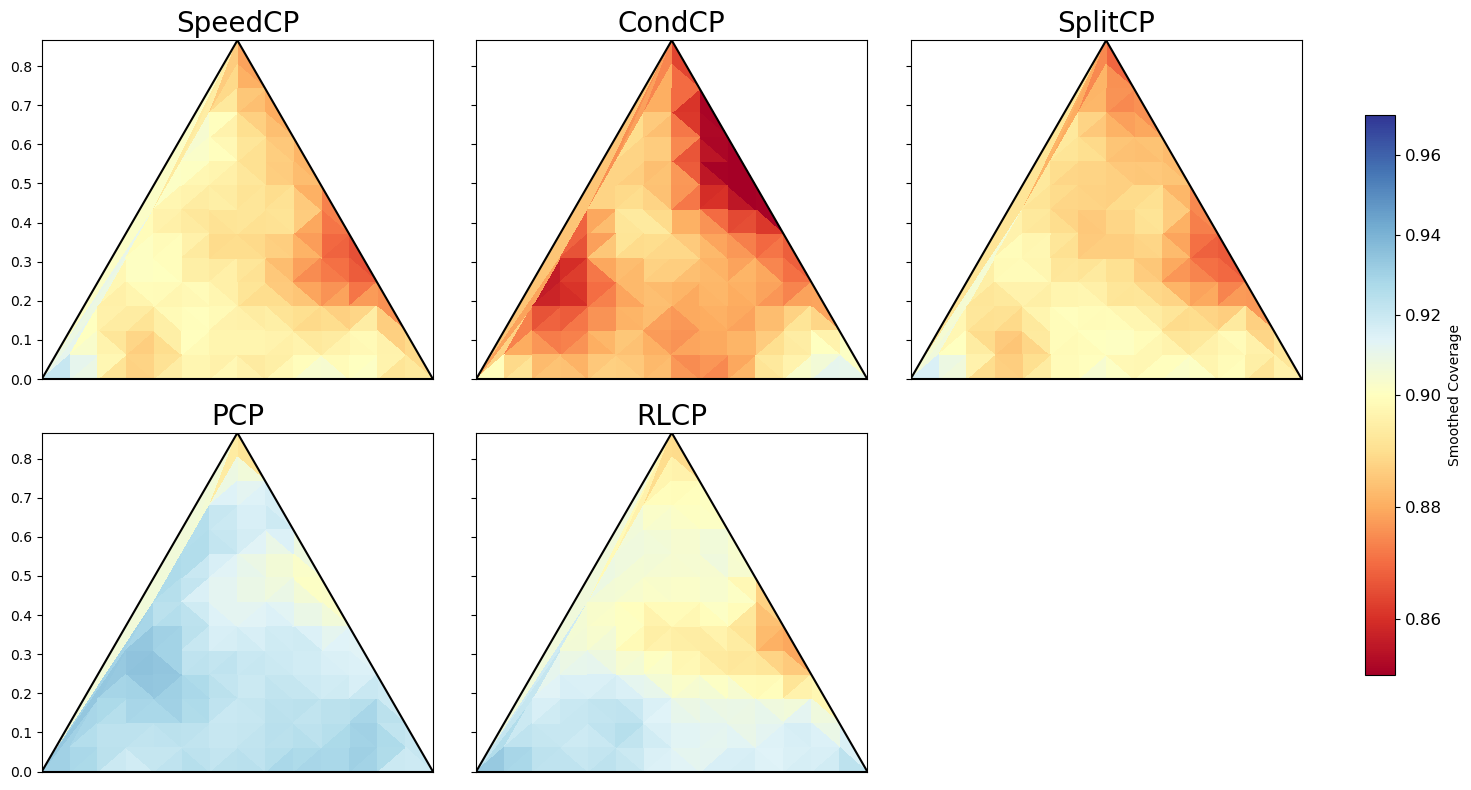

In [ ]:
def ternary_heatmap_all_methods(xy, cover_dict, method_names=None, cmap=plt.cm.RdYlBu, nbins=30):
    if method_names is None:
        method_names = list(cover_dict.keys())

    n_methods = len(method_names)
    n_cols = min(3, n_methods)
    n_rows = int(np.ceil(n_methods / n_cols))

    # Define triangle corners
    triangle = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]])
    
    # Create triangular grid
    x_vals = np.linspace(0, 1, nbins)
    y_vals = np.linspace(0, np.sqrt(3)/2, nbins)
    Xg, Yg = np.meshgrid(x_vals, y_vals)
    grid_points = np.vstack([Xg.ravel(), Yg.ravel()]).T

    # Mask points outside the triangle
    A = triangle[0]
    B = triangle[1]
    C = triangle[2]
    def in_triangle(p):
        v0 = C - A
        v1 = B - A
        v2 = p - A
        d00 = np.dot(v0, v0)
        d01 = np.dot(v0, v1)
        d11 = np.dot(v1, v1)
        d20 = np.dot(v2, v0)
        d21 = np.dot(v2, v1)
        denom = d00 * d11 - d01 * d01
        v = (d11 * d20 - d01 * d21) / denom
        w = (d00 * d21 - d01 * d20) / denom
        u = 1 - v - w
        return (u >= 0) & (v >= 0) & (w >= 0)

    mask = np.array([in_triangle(p) for p in grid_points])
    triangle_grid = grid_points[mask]

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=True, sharey=True)
    axs = np.array(axs).flatten()
    #norm = Normalize(vmin=0, vmax=1)
    norm = TwoSlopeNorm(vmin=0.85, vcenter=0.9, vmax=0.97)

    for i, method in enumerate(method_names):
        print(method)
        values = cover_dict[method]
        z_grid = np.full(len(triangle_grid), np.nan)

        radius = 2 / nbins
        for j, center in enumerate(triangle_grid):
            dists = np.linalg.norm(xy - center, axis=1)
            neighbors = values[dists < radius]
            if len(neighbors) > 0:
                z_grid[j] = neighbors.mean()

        ax = axs[i]
        sc = ax.tripcolor(
            triangle_grid[:, 0], triangle_grid[:, 1], z_grid,
            shading='flat', cmap=cmap, norm=norm
        )

        ax.plot(*triangle[[0, 1]].T, color='black')
        ax.plot(*triangle[[1, 2]].T, color='black')
        ax.plot(*triangle[[2, 0]].T, color='black')
        ax.set_title(f"{method}", fontsize=20) 
        ax.set_xlim(0, 1)
        ax.set_ylim(0, np.sqrt(3)/2)
        ax.set_aspect('equal')

    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])
    

    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    ax.set_xticks([])
    cbar = fig.colorbar(sc, cax=cbar_ax)
    cbar.set_label("Smoothed Coverage")
    cbar.ax.tick_params(labelsize=12)

    plt.tight_layout(rect=[0, 0, 0.9, 1])

W_all = np.vstack(W_all)
xy = barycentric_to_cartesian(W_all)
cover_dict = {k: np.hstack(v) for k, v in covers_list.items()}
ternary_heatmap_all_methods(xy, cover_dict, nbins=15)
plt.show()

In [13]:
f = coverage_df[coverage_df['shift_type']=='raw']
summary = coverage_df.groupby('method').agg({
    'coverage': ['mean', 'std'],
    'time': ['mean', 'std'],
    'cutoff': ['mean', 'std']
}).reset_index()

summary.columns = ['method', 'coverage_mean', 'coverage_sd', 'time_mean', 'time_sd', 'cutoff_mean', 'cutoff_sd']
summary = summary.round(3)

print(summary)

    method  coverage_mean  coverage_sd    time_mean  time_sd  cutoff_mean  \
0   CondCP          0.122        0.130  1332.675055  129.964        2.788   
1      PCP          0.075        0.061   141.648954   14.486        2.535   
2     RLCP          0.090        0.067     0.917958    0.110        2.225   
3  SpeedCP          0.105        0.068    22.054118    6.226        2.074   
4  SplitCP          0.107        0.069     0.000285    0.000        2.054   

   cutoff_sd  
0      0.722  
1      0.287  
2      0.213  
3      0.141  
4      0.120  
